In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
#from tensorflow.keras.callbacks import TQDMProgressBar
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [9]:
df = pd.read_csv('mel_dataset.csv', low_memory=False)
#tqdm_callback = TQDMProgressBar()

In [10]:
feature_cols = [col for col in df.columns if col.startswith('mel_')]
X = df[feature_cols].values
y = df['Ragas'].values
print("Shape of X before reshape:", X.shape)
print("Shape of y before encode:", y.shape)

Shape of X before reshape: (170, 165376)
Shape of y before encode: (170,)


In [11]:
# 2. Preprocessing
# Reshape the Mel Spectrograms into a 2D format
X_reshaped = X.reshape(170, 16, 10336, 1)

In [12]:
# Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))
y_categorical = to_categorical(y_encoded, num_classes=num_classes)
print("Shape of y_categorical before split:", y_categorical.shape)

Shape of y_categorical before split: (170, 9)


In [13]:
print(num_classes)

9


In [14]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_reshaped, y_categorical, test_size=0.2, random_state=42)

In [15]:
#2D CNN Model
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        # Convolutional Block 1
        #Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        #MaxPooling2D((2, 2)),

        # Convolutional Block 1
        Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),

        # Convolutional Block 2
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Flatten and Dense Layers
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5), # Dropout for regularization
        Dense(num_classes, activation='softmax') # Output layer
    ])
    return model

In [16]:
input_shape = (16, 10336, 1)
model = create_cnn_model(input_shape, num_classes=9)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 10334, 64)  │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 5167, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5165, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2582, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 660992)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   169,214,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,291,017 (645.79 MB)

 Trainable params: 169,291,017 (645.79 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(X_train, y_train,epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.1904 - loss: 1505.6224 - val_accuracy: 0.3235 - val_loss: 107.0116
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 226ms/step - accuracy: 0.2731 - loss: 92.5511 - val_accuracy: 0.4412 - val_loss: 1.9903
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.3076 - loss: 3.8755 - val_accuracy: 0.2941 - val_loss: 2.0015
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.4307 - loss: 1.9562 - val_accuracy: 0.2647 - val_loss: 2.0114
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.3884 - loss: 1.8851 - val_accuracy: 0.3235 - val_loss: 1.9991
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.3985 - loss: 2.3915 - val_accuracy: 0.2941 - val_loss: 1.9938
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.3581 - loss: 1.9077 - val_accuracy: 0.2941 - val_loss: 1.9896
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - accuracy: 0.3575 - loss: 2.1844 - val_accuracy: 0.2941 - val_

In [20]:
# 5. Evaluate the Model
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Loss: 1.9353
Validation Accuracy: 0.2647


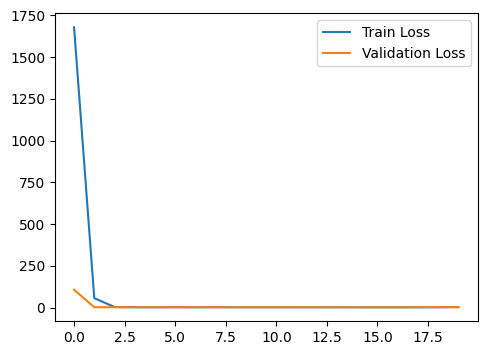

In [21]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()